In [2]:
# importing required libraries

!pip install kagglehub -q

import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("libraries loaded successfully")

libraries loaded successfully


In [3]:
# downloading the dataset from kaggle

dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/tuberculosis-tb-chest-xray-dataset"
)

print("dataset downloaded successfully")
print("dataset path:", dataset_path)
print("files and folders:", os.listdir(dataset_path))

100%|██████████| 663M/663M [00:39<00:00, 17.6MB/s]

Extracting files...


dataset downloaded successfully
dataset path: /root/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3
files and folders: ['TB_Chest_Radiography_Database']


In [4]:
# checking dataset folders

main_folder = os.path.join(
    dataset_path,
    "TB_Chest_Radiography_Database"
)

print("main folder:", main_folder)
print("\ncontents:")
print(os.listdir(main_folder))

main folder: /root/.cache/kagglehub/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset/versions/3/TB_Chest_Radiography_Database

contents:
['README.md.txt', 'Normal', 'Tuberculosis', 'Tuberculosis.metadata.xlsx', 'Normal.metadata.xlsx']


In [5]:
# checking class distribution

normal_path = os.path.join(main_folder, "Normal")
tb_path = os.path.join(main_folder, "Tuberculosis")

normal_count = len(os.listdir(normal_path))
tb_count = len(os.listdir(tb_path))

print("normal images:", normal_count)
print("tuberculosis images:", tb_count)
print("total images:", normal_count + tb_count)

normal images: 3500
tuberculosis images: 700
total images: 4200


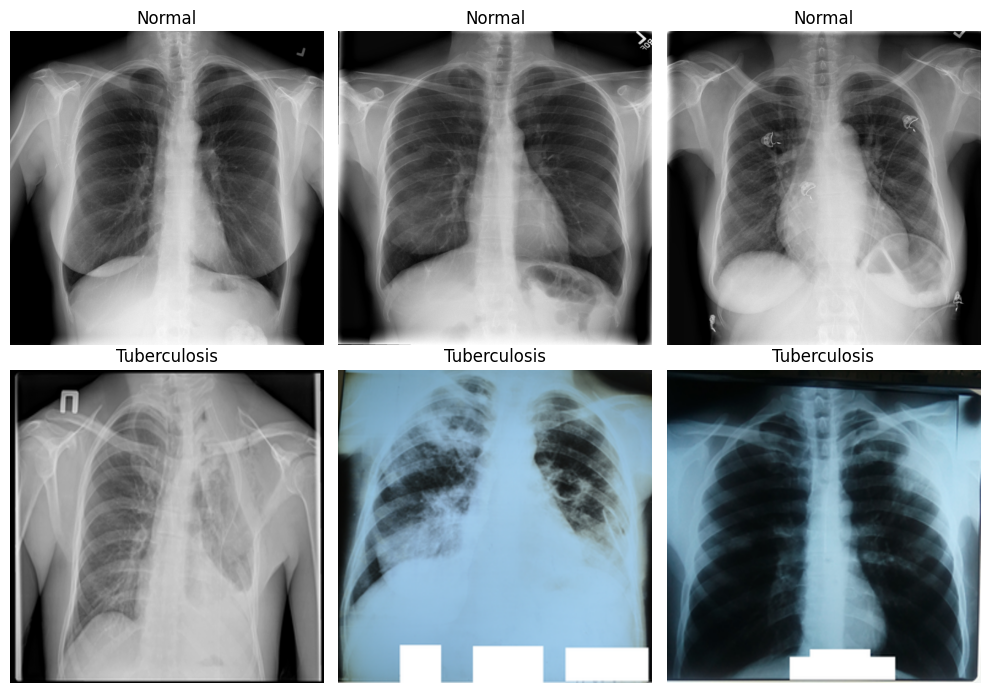

In [6]:
# displaying sample images from both classes

import random
from PIL import Image

normal_imgs = os.listdir(normal_path)
tb_imgs = os.listdir(tb_path)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i in range(3):
    img_path = os.path.join(normal_path, random.choice(normal_imgs))
    img = Image.open(img_path)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

for i in range(3):
    img_path = os.path.join(tb_path, random.choice(tb_imgs))
    img = Image.open(img_path)

    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title("Tuberculosis")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# checking image dimensions

from PIL import Image
import random

sample_normal = os.path.join(normal_path, random.choice(normal_imgs))
sample_tb = os.path.join(tb_path, random.choice(tb_imgs))

normal_img = Image.open(sample_normal)
tb_img = Image.open(sample_tb)

print("normal image size:", normal_img.size)
print("tb image size:", tb_img.size)
print("normal image mode:", normal_img.mode)
print("tb image mode:", tb_img.mode)

normal image size: (512, 512)
tb image size: (512, 512)
normal image mode: RGB
tb image mode: RGB


In [8]:
# preparing image paths and labels

normal_files = [os.path.join(normal_path, img) for img in os.listdir(normal_path)]
tb_files = [os.path.join(tb_path, img) for img in os.listdir(tb_path)]

normal_df = pd.DataFrame({
    "image_path": normal_files,
    "label": "Normal"
})

tb_df = pd.DataFrame({
    "image_path": tb_files,
    "label": "Tuberculosis"
})

data_df = pd.concat([normal_df, tb_df], ignore_index=True)

print(data_df.head())
print("\nclass distribution:")
print(data_df["label"].value_counts())
print("\ntotal records:", len(data_df))

                                          image_path   label
0  /root/.cache/kagglehub/datasets/tawsifurrahman...  Normal
1  /root/.cache/kagglehub/datasets/tawsifurrahman...  Normal
2  /root/.cache/kagglehub/datasets/tawsifurrahman...  Normal
3  /root/.cache/kagglehub/datasets/tawsifurrahman...  Normal
4  /root/.cache/kagglehub/datasets/tawsifurrahman...  Normal

class distribution:
label
Normal          3500
Tuberculosis     700
Name: count, dtype: int64

total records: 4200


In [9]:
# splitting data into train, validation and test sets

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    stratify=data_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("training set:", train_df.shape)
print(train_df["label"].value_counts())

print("\nvalidation set:", val_df.shape)
print(val_df["label"].value_counts())

print("\ntest set:", test_df.shape)
print(test_df["label"].value_counts())

training set: (2940, 2)
label
Normal          2450
Tuberculosis     490
Name: count, dtype: int64

validation set: (630, 2)
label
Normal          525
Tuberculosis    105
Name: count, dtype: int64

test set: (630, 2)
label
Normal          525
Tuberculosis    105
Name: count, dtype: int64


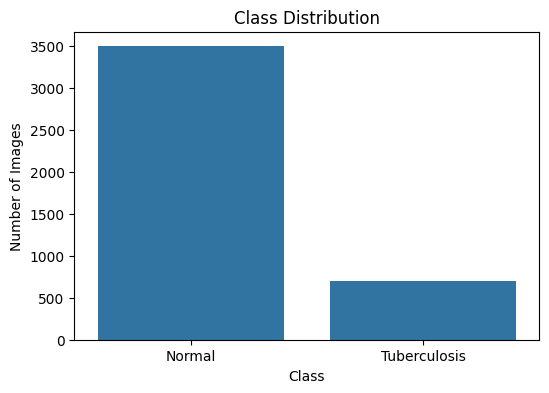

In [10]:
# visualizing class distribution

import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=data_df, x="label")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [11]:
# creating image generators

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_data = val_test_gen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_data = val_test_gen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 2940 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.


In [12]:
# checking class labels

print("class indices:", train_data.class_indices)

class indices: {'Normal': 0, 'Tuberculosis': 1}


In [13]:
# building the custom cnn model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

cnn_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# training the custom cnn model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

cnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "custom_cnn_best_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=cnn_callbacks
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.8953 - loss: 0.5137

92/92 ━━━━━━━━━━━━━━━━━━━━ 87s 837ms/step - accuracy: 0.9204 - loss: 0.3786 - val_accuracy: 0.7937 - val_loss: 0.4494
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 718ms/step - accuracy: 0.9429 - loss: 0.1836 - val_accuracy: 0.4190 - val_loss: 1.8741
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 710ms/step - accuracy: 0.9554 - loss: 0.1458 - val_accuracy: 0.7222 - val_loss: 1.1072
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 716ms/step - accuracy: 0.9643 - loss: 0.1099 - val_accuracy: 0.7381 - val_loss: 1.5822
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9591 - loss: 0.1328

92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 721ms/step - accuracy: 0.9653 - loss: 0.1330 - val_accuracy: 0.8206 - val_loss: 0.7982


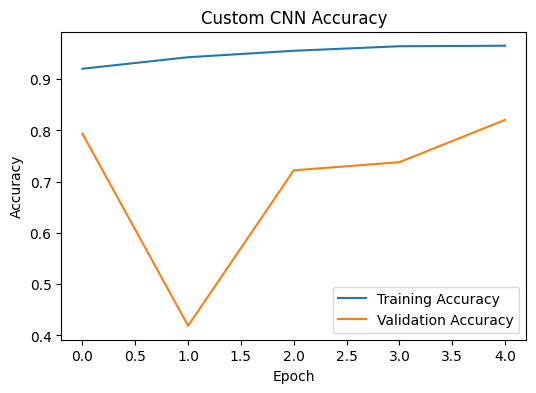

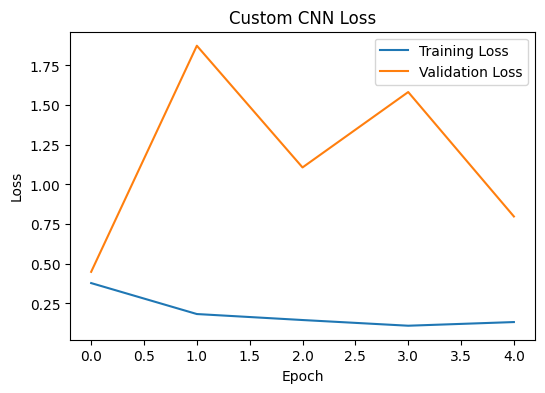

In [15]:
# plotting cnn training performance

plt.figure(figsize=(6,4))
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
# evaluating the custom cnn model

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_data)

print("test loss:", round(cnn_test_loss, 4))
print("test accuracy:", round(cnn_test_acc, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step - accuracy: 0.7841 - loss: 0.4665
test loss: 0.4665
test accuracy: 0.7841


In [17]:
# generating predictions from cnn model

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_true = test_data.classes

y_pred_prob = cnn_model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_true, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       525
           1       0.42      0.72      0.53       105

    accuracy                           0.78       630
   macro avg       0.68      0.76      0.69       630
weighted avg       0.85      0.78      0.80       630



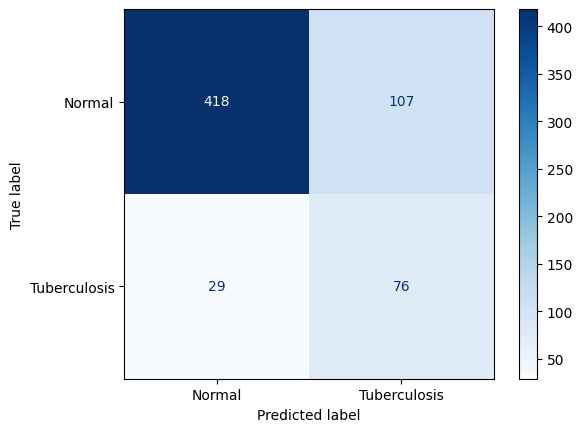

In [18]:
# plotting confusion matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Tuberculosis"]
)

disp.plot(cmap="Blues")
plt.show()

In [19]:
# building mobilenetv2 transfer learning model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# training mobilenetv2 model

mobilenet_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "mobilenet_best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=mobilenet_callbacks
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9459 - loss: 0.1522 - val_accuracy: 0.9587 - val_loss: 0.1037
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 71s 776ms/step - accuracy: 0.9765 - loss: 0.0592 - val_accuracy: 0.9556 - val_loss: 0.1149
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 793ms/step - accuracy: 0.9816 - loss: 0.0465 - val_accuracy: 0.9460 - val_loss: 0.1649
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 783ms/step - accuracy: 0.9871 - loss: 0.0480 - val_accuracy: 0.9587 - val_loss: 0.1401
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 782ms/step - accuracy: 0.9864 - loss: 0.0356 - val_accuracy: 0.9571 - val_loss: 0.1464


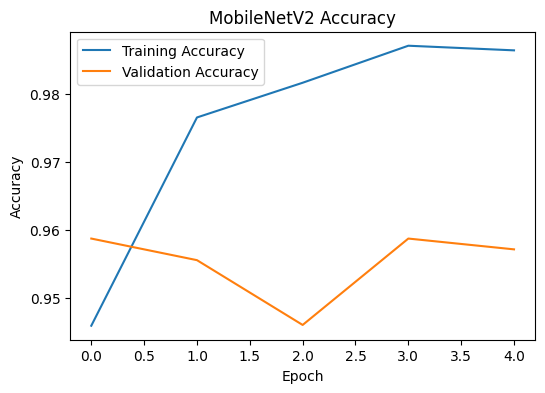

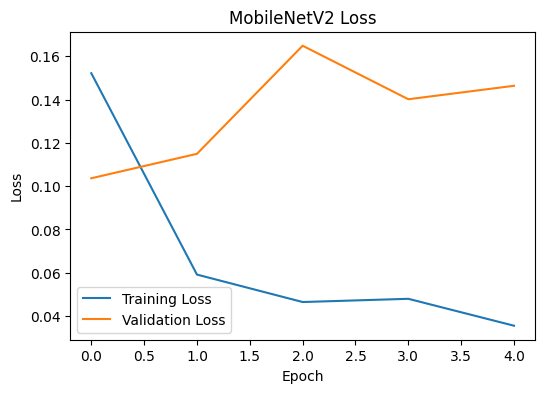

In [21]:
# plotting mobilenetv2 training performance

plt.figure(figsize=(6,4))
plt.plot(mobilenet_history.history["accuracy"], label="Training Accuracy")
plt.plot(mobilenet_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(mobilenet_history.history["loss"], label="Training Loss")
plt.plot(mobilenet_history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [22]:
# evaluating mobilenetv2 on test data

mobile_test_loss, mobile_test_acc = mobilenet_model.evaluate(test_data)

print("test loss:", round(mobile_test_loss, 4))
print("test accuracy:", round(mobile_test_acc, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 360ms/step - accuracy: 0.9730 - loss: 0.0663
test loss: 0.0663
test accuracy: 0.973


In [23]:
# generating mobilenet predictions

mobile_y_true = test_data.classes

mobile_y_pred_prob = mobilenet_model.predict(test_data)
mobile_y_pred = (mobile_y_pred_prob > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(mobile_y_true, mobile_y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 712ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       525
           1       1.00      0.84      0.91       105

    accuracy                           0.97       630
   macro avg       0.98      0.92      0.95       630
weighted avg       0.97      0.97      0.97       630



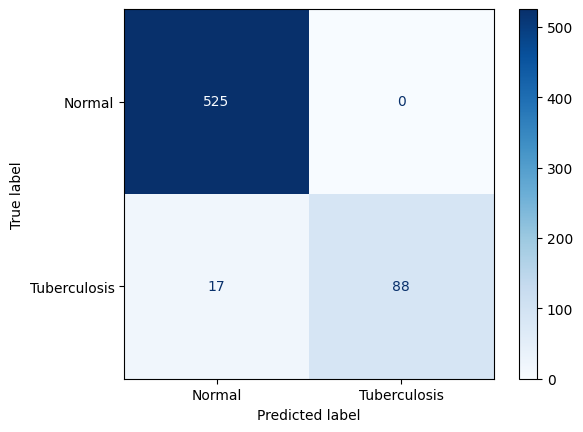

In [24]:
# plotting mobilenet confusion matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

mobile_cm = confusion_matrix(
    mobile_y_true,
    mobile_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=mobile_cm,
    display_labels=["Normal", "Tuberculosis"]
)

disp.plot(cmap="Blues")
plt.show()

In [25]:
# saving the final model

mobilenet_model.save("tb_mobilenetv2_model.keras")

print("model saved successfully")

model saved successfully


In [26]:
# checking saved files

import os

for file in os.listdir():
    if file.endswith(".keras") or file.endswith(".h5"):
        print(file)

mobilenet_best_model.keras
custom_cnn_best_model.h5
tb_mobilenetv2_model.keras
